<a href="https://colab.research.google.com/github/Jtuaz/Projects-Portfolio-/blob/main/Alzheimer_Classifcation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CSV loaded: 1688 rows
Found scans: 1550
Train / Val sizes: 1234 / 316
Detected labels: {'AD': 0, 'MCI': 1, 'NC': 2}

=== Dataset Summary: Patients and Scans per Diagnosis ===

       Unique_Patients  Total_Scans
label                              
NC                 310         1301
MCI                 63          270
AD                  26          117

Detailed counts per diagnosis:
  NC: 310 patients, 1301 scans
  MCI: 63 patients, 270 scans
  AD: 26 patients, 117 scans

=== Overall Totals ===
Total unique patients: 399
Total scans: 1688


Epoch 1 [Val]: 100%|████████████████████████| 79/79 [02:47<00:00,  2.12s/it, Loss=0.4898, Acc=0.804]



Epoch 001 Summary | Train: loss=0.6400, acc=0.7763 | Val: loss=0.4898, acc=0.8038
Saved best checkpoint.


Epoch 2 [Val]: 100%|████████████████████████| 79/79 [01:03<00:00,  1.25it/s, Loss=0.7062, Acc=0.778]



Epoch 002 Summary | Train: loss=0.5433, acc=0.7812 | Val: loss=0.7062, acc=0.7785


...


Epoch 003 Summary | Train: loss=0.5295, acc=0.7804 | Val: loss=0.5112, acc=0.8006


Epoch 4 [Val]: 100%|████████████████████████| 79/79 [01:01<00:00,  1.28it/s, Loss=0.4492, Acc=0.801]



Epoch 004 Summary | Train: loss=0.5248, acc=0.7780 | Val: loss=0.4492, acc=0.8006


Epoch 5 [Val]: 100%|████████████████████████| 79/79 [01:01<00:00,  1.27it/s, Loss=0.4360, Acc=0.794]



Epoch 005 Summary | Train: loss=0.5174, acc=0.7755 | Val: loss=0.4360, acc=0.7943

Evaluating confusion matrix on validation set...


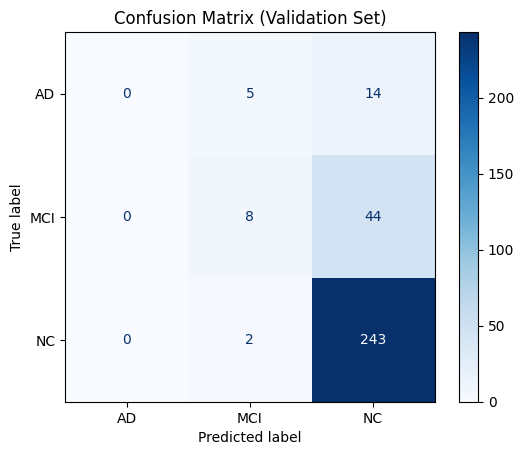


Training complete. Best validation accuracy: 0.8038


In [ ]:
!pip install -q nibabel

from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import random
from pathlib import Path
from typing import List, Tuple, Dict

import numpy as np
import nibabel as nib
from scipy.ndimage import zoom
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from tqdm import tqdm
from torchvision.models.video import r3d_18, R3D_18_Weights

# Configuration and Hyperparameters
DATASET_ROOT_DIRECTORY = "/content/drive/MyDrive/OASIS-1_Process"
COMMA_SEPARATED_VALUES_PATH = os.path.join(DATASET_ROOT_DIRECTORY, "oasis_labels.csv")
COMPUTATION_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUMBER_OF_CLASSES = 3
TARGET_VOLUME_SHAPE = (128, 128, 128)
BATCH_SIZE = 4
NUMBER_OF_EPOCHS = 5
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
NUMBER_OF_WORKERS = 2
PIN_MEMORY = True if COMPUTATION_DEVICE == "cuda" else False
CHECKPOINT_SAVE_DIRECTORY = "/content/drive/MyDrive/checkpoints_oasis"
RANDOM_SEED = 42

# Ensure the checkpoint directory exists
os.makedirs(CHECKPOINT_SAVE_DIRECTORY, exist_ok=True)

# Set random seeds for reproducibility across packages
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if COMPUTATION_DEVICE == "cuda":
    torch.cuda.manual_seed_all(RANDOM_SEED)


def find_scan_file(data_root_directory: str, session_identifier: str, scan_identifier: str) -> str:
    """Search for the matching NIfTI scan file within the brain extraction tool (BET) directory."""
    brain_extraction_directory = os.path.join(data_root_directory, session_identifier, "BET")

    # Handle alternative directory matching if primary path is missing
    if not os.path.isdir(brain_extraction_directory):
        session_glob_matches = glob.glob(os.path.join(data_root_directory, f"{session_identifier}*"))
        for single_session in session_glob_matches:
            alternative_path = os.path.join(single_session, "BET")
            if os.path.isdir(alternative_path):
                brain_extraction_directory = alternative_path
                break

    # Build glob pattern to locate matching .nii or .nii.gz file
    file_pattern = os.path.join(brain_extraction_directory, f"*{scan_identifier}*")
    matching_file_paths = (
            glob.glob(file_pattern + ".nii") +
            glob.glob(file_pattern + ".nii.gz") +
            glob.glob(file_pattern + "*")
    )

    if not matching_file_paths:
        matching_file_paths = glob.glob(os.path.join(data_root_directory, session_identifier, "BET", "*"))

    for single_match in matching_file_paths:
        if scan_identifier in os.path.basename(single_match):
            return single_match

    return matching_file_paths[0] if matching_file_paths else None


def load_nifti(file_path: str) -> np.ndarray:
    """Load a NIfTI volume from disk and return as a float32 NumPy array."""
    nifti_image = nib.load(file_path)
    return nifti_image.get_fdata(dtype=np.float32)


def resample_to_shape(input_volume: np.ndarray, target_shape: Tuple[int, int, int]) -> np.ndarray:
    """Resample input 3D volume to target spatial shape using trilinear interpolation."""
    resampling_zoom_factors = [target_dim / source_dim for source_dim, target_dim in
                               zip(input_volume.shape, target_shape)]
    return zoom(input_volume, zoom=resampling_zoom_factors, order=1)


def normalize_intensity(input_volume: np.ndarray) -> np.ndarray:
    """Clip intensity percentiles (1st to 99th) and apply z-score normalization."""
    volume_copy = input_volume.copy()
    first_percentile, ninety_ninth_percentile = np.percentile(volume_copy, (1, 99))
    volume_copy = np.clip(volume_copy, first_percentile, ninety_ninth_percentile)

    mean_intensity = volume_copy.mean()
    standard_deviation = volume_copy.std() if volume_copy.std() > 0 else 1.0

    normalized_volume = (volume_copy - mean_intensity) / standard_deviation
    return normalized_volume.astype(np.float32)


class OASISDataset(Dataset):
    """Custom Dataset for loading, resampling, normalizing, and augmenting 3D OASIS MRI volumes."""

    def __init__(self, record_list: List[Dict], data_root_directory: str, target_shape: Tuple[int, int, int],
                 label_map: Dict[str, int], augment: bool = False):
        self.record_list = record_list
        self.data_root_directory = data_root_directory
        self.target_shape = target_shape
        self.label_map = label_map
        self.augment = augment

    def __len__(self):
        return len(self.record_list)

    def __getitem__(self, index_value):
        single_record = self.record_list[index_value]
        session_identifier = single_record["session_id"]
        scan_identifier = single_record["scan_id"]
        label_string = single_record["label"]
        class_label = self.label_map[label_string]

        scan_file_path = find_scan_file(self.data_root_directory, session_identifier, scan_identifier)
        if scan_file_path is None:
            raise FileNotFoundError(f"No scan file found for {session_identifier} {scan_identifier}")

        mri_volume = load_nifti(scan_file_path)
        mri_volume = resample_to_shape(mri_volume, self.target_shape)
        mri_volume = normalize_intensity(mri_volume)

        # Apply random spatial flips if augmentation is enabled
        if self.augment:
            if random.random() < 0.5:
                mri_volume = np.flip(mri_volume, axis=0).copy()  # Flip along first dimension
            if random.random() < 0.5:
                mri_volume = np.flip(mri_volume, axis=1).copy()  # Flip along second dimension

        # Expand channel dimension (C, D, H, W)
        mri_volume = np.expand_dims(mri_volume, axis=0)
        return torch.from_numpy(mri_volume).float(), torch.tensor(class_label, dtype=torch.long)


class ConvBlock(nn.Module):
    """Double 3D Convolutional block with Batch Normalization and ReLU activation."""

    def __init__(self, input_channels: int, output_channels: int):
        super().__init__()
        self.first_convolution = nn.Conv3d(input_channels, output_channels, kernel_size=3, padding=1)
        self.first_batch_norm = nn.BatchNorm3d(output_channels)
        self.second_convolution = nn.Conv3d(output_channels, output_channels, kernel_size=3, padding=1)
        self.second_batch_norm = nn.BatchNorm3d(output_channels)
        self.activation_function = nn.ReLU(inplace=True)

    def forward(self, input_tensor):
        input_tensor = self.activation_function(self.first_batch_norm(self.first_convolution(input_tensor)))
        input_tensor = self.activation_function(self.second_batch_norm(self.second_convolution(input_tensor)))
        return input_tensor


class Down(nn.Module):
    """Downsampling block with MaxPool3D followed by a ConvBlock."""

    def __init__(self, input_channels: int, output_channels: int):
        super().__init__()
        self.max_pooling = nn.MaxPool3d(2)
        self.conv_block = ConvBlock(input_channels, output_channels)

    def forward(self, input_tensor):
        input_tensor = self.max_pooling(input_tensor)
        input_tensor = self.conv_block(input_tensor)
        return input_tensor


class Simple3DCnn(nn.Module):
    """Lightweight 3D CNN baseline for volumetric image classification."""

    def __init__(self, input_channels: int = 1, number_of_classes: int = 3):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv3d(input_channels, 8, kernel_size=3, padding=1),
            nn.BatchNorm3d(8),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            nn.Conv3d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool3d(1)
        )
        self.classifier_head = nn.Linear(32, number_of_classes)

    def forward(self, input_tensor):
        input_tensor = self.feature_extractor(input_tensor)
        input_tensor = input_tensor.view(input_tensor.size(0), -1)
        return self.classifier_head(input_tensor)


class VNetSimple(nn.Module):
    """V-Net inspired encoder architecture for 3D classification."""

    def __init__(self, input_channels: int = 1, base_channels: int = 16, number_of_classes: int = 2):
        super().__init__()
        self.first_encoder = ConvBlock(input_channels, base_channels)
        self.first_downsample = Down(base_channels, base_channels * 2)
        self.second_downsample = Down(base_channels * 2, base_channels * 4)
        self.third_downsample = Down(base_channels * 4, base_channels * 8)
        self.bottleneck_block = ConvBlock(base_channels * 8, base_channels * 8)
        self.global_average_pool = nn.AdaptiveAvgPool3d(1)
        self.fully_connected_layer = nn.Linear(base_channels * 8, number_of_classes)

    def forward(self, input_tensor):
        input_tensor = self.first_encoder(input_tensor)
        input_tensor = self.first_downsample(input_tensor)
        input_tensor = self.second_downsample(input_tensor)
        input_tensor = self.third_downsample(input_tensor)
        input_tensor = self.bottleneck_block(input_tensor)
        global_features = self.global_average_pool(input_tensor).view(input_tensor.size(0), -1)
        return self.fully_connected_layer(global_features)


def buildResNet3D(number_of_classes: int):
    """Builds a 3D ResNet18 model adapted for single-channel grayscale volumes."""
    resnet_model = r3d_18(weights=None)

    # Modify initial conv layer stem to accept 1 channel instead of 3
    resnet_model.stem[0] = nn.Conv3d(
        1,
        64,
        kernel_size=(3, 7, 7),
        stride=(1, 2, 2),
        padding=(1, 3, 3),
        bias=False
    )

    resnet_model.fc = nn.Linear(resnet_model.fc.in_features, number_of_classes)
    return resnet_model


def train_one_epoch(network_model, data_loader, loss_optimizer, loss_criterion, target_device, current_epoch):
    """Executes single training epoch and reports loss and accuracy."""
    network_model.train()
    accumulated_loss, total_correct_predictions, total_samples = 0.0, 0, 0
    progress_bar = tqdm(data_loader, desc=f"Epoch {current_epoch} [Train]", ncols=100)

    for x_batch, y_batch in progress_bar:
        x_batch, y_batch = x_batch.to(target_device), y_batch.to(target_device)

        loss_optimizer.zero_grad()
        model_predictions = network_model(x_batch)
        loss_value = loss_criterion(model_predictions, y_batch)
        loss_value.backward()
        loss_optimizer.step()

        accumulated_loss += loss_value.item() * x_batch.size(0)
        class_predictions = model_predictions.argmax(dim=1)
        total_correct_predictions += (class_predictions == y_batch).sum().item()
        total_samples += x_batch.size(0)

        progress_bar.set_postfix({
            "Loss": f"{accumulated_loss / total_samples:.4f}",
            "Acc": f"{total_correct_predictions / total_samples:.3f}"
        })

    return accumulated_loss / total_samples, total_correct_predictions / total_samples


def evaluate(network_model, data_loader, loss_criterion, target_device, current_epoch):
    """Evaluates network model performance on validation dataset."""
    network_model.eval()
    accumulated_loss, total_correct_predictions, total_samples = 0.0, 0, 0
    progress_bar = tqdm(data_loader, desc=f"Epoch {current_epoch} [Val]", ncols=100)

    with torch.no_grad():
        for x_batch, y_batch in progress_bar:
            x_batch, y_batch = x_batch.to(target_device), y_batch.to(target_device)
            model_predictions = network_model(x_batch)
            loss_value = loss_criterion(model_predictions, y_batch)

            accumulated_loss += loss_value.item() * x_batch.size(0)
            class_predictions = model_predictions.argmax(dim=1)
            total_correct_predictions += (class_predictions == y_batch).sum().item()
            total_samples += x_batch.size(0)

            progress_bar.set_postfix({
                "Loss": f"{accumulated_loss / total_samples:.4f}",
                "Acc": f"{total_correct_predictions / total_samples:.3f}"
            })

    return accumulated_loss / total_samples, total_correct_predictions / total_samples


def get_predictions(network_model, data_loader, target_device):
    """Collects ground truth and predicted class labels across validation set."""
    network_model.eval()
    accumulated_predictions, accumulated_labels = [], []

    with torch.no_grad():
        for x_batch, y_batch in tqdm(data_loader, desc="Collecting predictions"):
            x_batch = x_batch.to(target_device)
            model_predictions = network_model(x_batch)
            class_predictions = model_predictions.argmax(dim=1).cpu().numpy()

            accumulated_predictions.extend(class_predictions)
            accumulated_labels.extend(y_batch.numpy())

    return np.array(accumulated_labels), np.array(accumulated_predictions)


def main():
    # Load dataset index from CSV
    dataframe_labels = pd.read_csv(COMMA_SEPARATED_VALUES_PATH)
    print("CSV loaded:", len(dataframe_labels), "rows")

    if not {"session_id", "scan_id", "label"}.issubset(dataframe_labels.columns):
        raise ValueError("CSV must contain columns: session_id, scan_id, label")

    # Format table into record dictionaries
    record_dictionaries = dataframe_labels.to_dict(orient="records")

    # Filter scans to keep only those that exist on local storage
    existing_scan_records = [
        single_record for single_record in record_dictionaries
        if find_scan_file(DATASET_ROOT_DIRECTORY, single_record["session_id"], single_record["scan_id"])
    ]
    print("Found scans:", len(existing_scan_records))
    record_dictionaries = existing_scan_records

    # Group patient IDs to prevent data leakage between train/validation splits
    unique_patients_dataframe = pd.DataFrame(record_dictionaries).drop_duplicates(subset='session_id')
    patient_identifiers = unique_patients_dataframe['session_id'].values
    patient_diagnostic_labels = unique_patients_dataframe['label'].values

    # Perform stratified split at patient level
    train_patient_identifiers, validation_patient_identifiers = train_test_split(
        patient_identifiers,
        test_size=0.2,
        stratify=patient_diagnostic_labels,
        random_state=RANDOM_SEED
    )

    # Assign scan records to respective splits based on patient mapping
    train_records = [rec for rec in record_dictionaries if rec['session_id'] in train_patient_identifiers]
    validation_records = [rec for rec in record_dictionaries if rec['session_id'] in validation_patient_identifiers]

    print("Train / Val sizes:", len(train_records), "/", len(validation_records))

    # Map text labels to categorical integer indices
    unique_sorted_labels = sorted(dataframe_labels["label"].dropna().unique().tolist())
    dataset_label_mapping = {label_name: index for index, label_name in enumerate(unique_sorted_labels)}

    global NUMBER_OF_CLASSES
    NUMBER_OF_CLASSES = len(unique_sorted_labels)
    print("Detected labels:", dataset_label_mapping)

    # Output dataset breakdown summary statistics
    total_scan_counts = dataframe_labels['label'].value_counts()
    unique_patient_counts = unique_patients_dataframe['label'].value_counts()
    summary_dataframe = pd.DataFrame({
        'Unique_Patients': unique_patient_counts,
        'Total_Scans': total_scan_counts
    }).fillna(0).astype(int)

    total_unique_patient_count = unique_patients_dataframe['session_id'].nunique()
    total_scan_count = len(dataframe_labels)

    print("\n=== Dataset Summary: Patients and Scans per Diagnosis ===\n")
    print(summary_dataframe)
    print("\nDetailed counts per diagnosis:")
    for diagnosis_label, summary_row in summary_dataframe.iterrows():
        print(f"  {diagnosis_label}: {summary_row['Unique_Patients']} patients, {summary_row['Total_Scans']} scans")
    print("\n=== Overall Totals ===")
    print(f"Total unique patients: {total_unique_patient_count}")
    print(f"Total scans: {total_scan_count}")

    # Instantiate PyTorch Datasets and DataLoaders
    train_dataset = OASISDataset(train_records, DATASET_ROOT_DIRECTORY, TARGET_VOLUME_SHAPE, dataset_label_mapping,
                                 augment=True)
    validation_dataset = OASISDataset(validation_records, DATASET_ROOT_DIRECTORY, TARGET_VOLUME_SHAPE,
                                      dataset_label_mapping, augment=False)

    train_data_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUMBER_OF_WORKERS,
        pin_memory=PIN_MEMORY
    )

    validation_data_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUMBER_OF_WORKERS,
        pin_memory=PIN_MEMORY
    )

    # Initialize model, loss criteria, and optimization algorithm
    neural_network_model = VNetSimple(input_channels=1, base_channels=16, number_of_classes=NUMBER_OF_CLASSES).to(
        COMPUTATION_DEVICE)
    loss_criterion = nn.CrossEntropyLoss()
    model_optimizer = Adam(neural_network_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # Execute training loop across epochs
    best_validation_accuracy = 0.0
    for current_epoch in range(1, NUMBER_OF_EPOCHS + 1):
        train_loss, train_accuracy = train_one_epoch(
            neural_network_model, train_data_loader, model_optimizer, loss_criterion, COMPUTATION_DEVICE, current_epoch
        )
        validation_loss, validation_accuracy = evaluate(
            neural_network_model, validation_data_loader, loss_criterion, COMPUTATION_DEVICE, current_epoch
        )

        print(f"\nEpoch {current_epoch:03d} Summary | Train: loss={train_loss:.4f}, acc={train_accuracy:.4f} | "
              f"Val: loss={validation_loss:.4f}, acc={validation_accuracy:.4f}")

        # Save checkpoint if current validation accuracy improves upon previous best
        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_accuracy
            checkpoint_file_path = os.path.join(CHECKPOINT_SAVE_DIRECTORY,
                                                f"vnet_best_epoch{current_epoch}_acc{validation_accuracy:.4f}.pth")
            torch.save({
                "epoch": current_epoch,
                "model_state": neural_network_model.state_dict(),
                "optimizer_state": model_optimizer.state_dict(),
                "val_acc": validation_accuracy,
                "label_map": dataset_label_mapping
            }, checkpoint_file_path)
            print("Saved best checkpoint.")

    # Generate and display final validation confusion matrix
    print("\nEvaluating confusion matrix on validation set...")
    ground_truth_labels, predicted_labels = get_predictions(neural_network_model, validation_data_loader,
                                                            COMPUTATION_DEVICE)
    computed_confusion_matrix = confusion_matrix(ground_truth_labels, predicted_labels)
    matrix_display = ConfusionMatrixDisplay(confusion_matrix=computed_confusion_matrix,
                                            display_labels=list(dataset_label_mapping.keys()))
    matrix_display.plot(cmap="Blues", values_format="d")
    plt.title("Confusion Matrix (Validation Set)")
    plt.show()

    print(f"\nTraining complete. Best validation accuracy: {best_validation_accuracy:.4f}")


if __name__ == "__main__":
    main()